<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/05_def.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(def-notebook)=
# La percezione dell'orientamento locale della superfice

## Preparazione del Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pymc.sampling_jax
import arviz as az
from pymc import HalfCauchy, Model, Normal, sample

/Users/corrado/mambaforge/envs/pymc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
N = 100
sigma_degress = np.random.uniform(10, 80, size=N)
sigma_radians = np.deg2rad(sigma_degress)

omega_degrees_per_second = np.random.uniform(0, 180, size=N)
omega_radians_per_second = np.deg2rad(omega_degrees_per_second)

def_values = sigma_radians * omega_radians_per_second

noise_std_dev = 0.1

def_data = def_values + np.random.normal(0, noise_std_dev, def_values.shape)

In [4]:
with Model() as model:
    s = pm.Beta("s", alpha=1, beta=1, shape=N)  # Slant per ogni misurazione
    omega = pm.Beta(
        "omega", alpha=1, beta=1, shape=N
    )  # Velocità di rotazione locale per ogni misurazione
    sigma = pm.HalfNormal(
        "sigma", sigma=1
    )  # Deviazione standard, assunta come HalfNormal per la positività

    # Likelihood
    def_expected = s * omega  # Media prevista per la distribuzione normale
    def_obs = pm.Normal(
        "def", mu=def_expected, sigma=sigma, observed=def_data
    )  # Likelihood

In [5]:
with model:
    idata = pm.sampling_jax.sample_numpyro_nuts()

Compiling...
Compilation time = 0:00:02.774367
Sampling...
Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:03<?, ?it/s]




Running chain 0:   5%|▌         | 100/2000 [00:04<00:03, 505.00it/s]



Running chain 0:  25%|██▌       | 500/2000 [00:04<00:00, 1647.82it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:04<00:00, 2286.95it/s]


Running chain 0:  65%|██████▌   | 1300/2000 [00:04<00:00, 2613.32it/s]


Running chain 0:  80%|████████  | 1600/2000 [00:04<00:00, 2677.81it/s]


Running chain 3: 100%|██████████| 2000/2000 [00:04<00:00, 415.61it/s] 
Sampling time = 0:00:05.570769
Transforming variables...
Transformation time = 0:00:00.255745


In [7]:
# Extract samples for the variable 's'
s_samples = idata.posterior["s"].values

# Extract samples for the variable 'omega'
omega_samples = idata.posterior["omega"].values

In [8]:
s_mean = np.mean(s_samples, axis=(0, 1))
omega_mean = np.mean(omega_samples, axis=(0, 1))

# Let's print the shapes again to verify the correction
print("Corrected shape of s_mean:", s_mean.shape)
print("Corrected shape of omega_mean:", omega_mean.shape)

Corrected shape of s_mean: (100,)
Corrected shape of omega_mean: (100,)


In [9]:
sqrt_def = np.sqrt(def_values)
sqrt_def.shape

(100,)

/var/folders/hl/dt523djx7_q7xjrthzjpdvc40000gn/T/ipykernel_20691/805259755.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


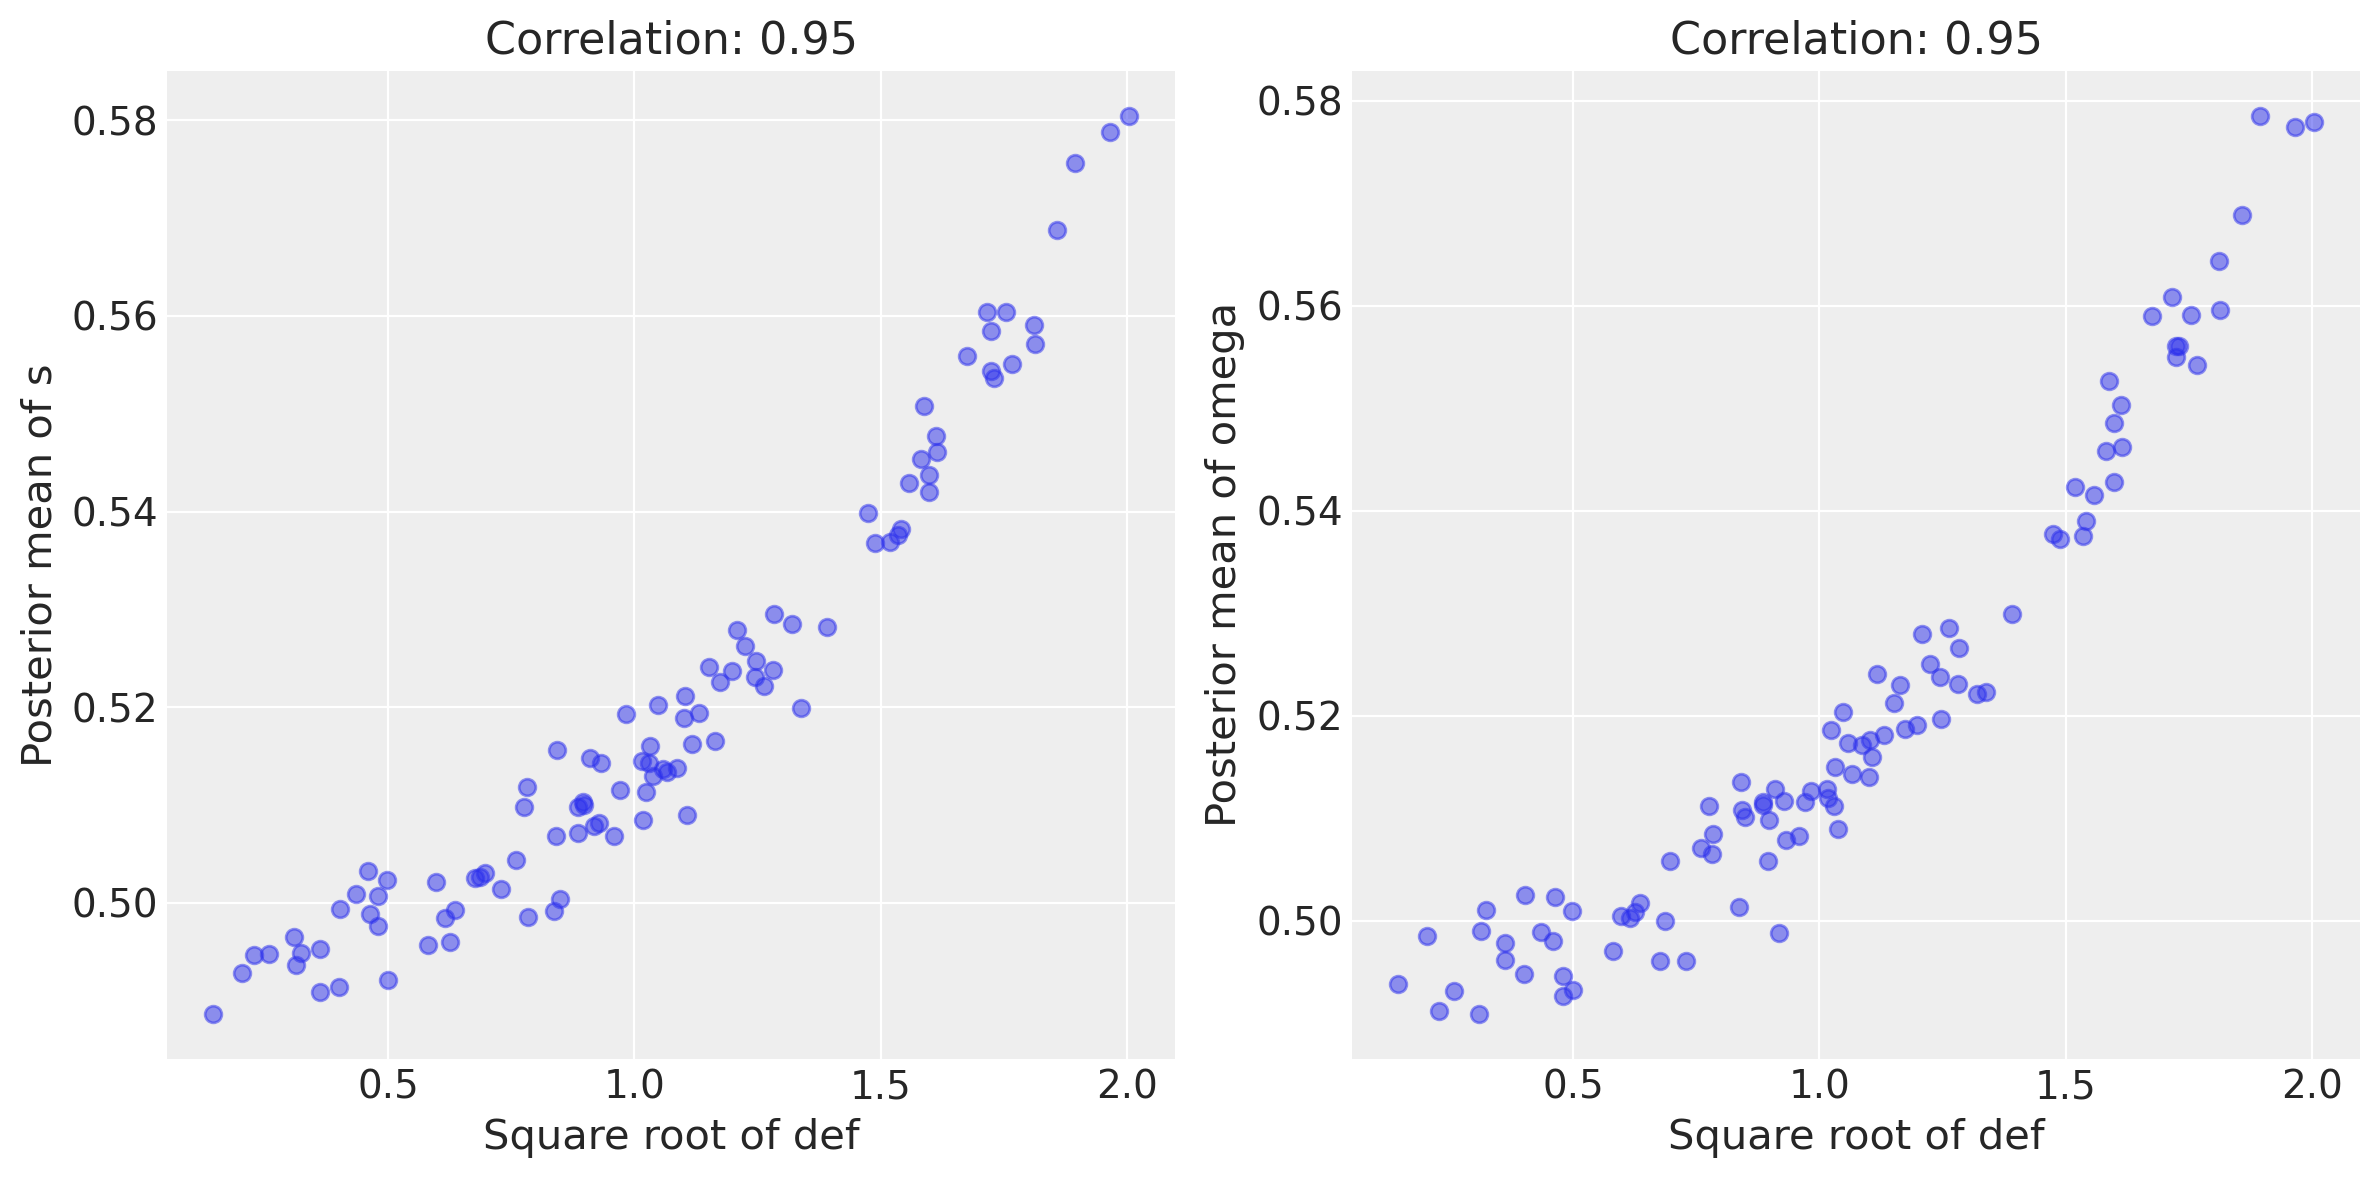

In [10]:
# Calculate correlations
cor_s = np.corrcoef(sqrt_def, s_mean)[0, 1]
cor_omega = np.corrcoef(sqrt_def, omega_mean)[0, 1]

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(sqrt_def, s_mean, alpha=0.5)
plt.xlabel("Square root of def")
plt.ylabel("Posterior mean of s")
plt.title(f"Correlation: {cor_s:.2f}")

plt.subplot(1, 2, 2)
plt.scatter(sqrt_def, omega_mean, alpha=0.5)
plt.xlabel("Square root of def")
plt.ylabel("Posterior mean of omega")
plt.title(f"Correlation: {cor_omega:.2f}")

plt.tight_layout()
plt.show()